In [28]:
import os
print(os.listdir())

['.config', 'hate_speech_project_dataset31.csv', 'sample_data']


In [29]:
import pandas as pd

df = pd.read_csv("hate_speech_project_dataset31.csv", encoding="utf-8")

print(df.head())
print(df.shape)
print(df.columns)

                                     HateSpeech                 HateType  \
0  واحد من جماعتكم دايم يتكبر كأنه أحسن من الكل   Nationality-based hate   
1                   لهجتكم تضحك وما تنفهم أصلاً  Appearance-based attack   
2               البنات من منطقتكم ما عندهم طموح                   Sexism   
3                         دينكم كله تشدد وتعقيد           Religious hate   
4                         واضح من شكلك إنك مهمل  Appearance-based attack   

                                    CounterSpeech               Strategy  \
0      التعميم ما ينصف، كل مجتمع فيه الزين والشين      Calm disagreement   
1  الاختلاف في اللهجات يثري اللغة وما يقلل من أحد     Positive reframing   
2          هذا حكم غير عادل، في نماذج ناجحة كثيرة  Fact-based correction   
3           فهم الدين يختلف، والأفضل الحوار بهدوء          De-escalation   
4          المظهر ما يعكس القيمة الحقيقية للإنسان                Empathy   

  Dialect                          Explanation  
0     GCC       Corrects generalizati

In [30]:
import pandas as pd

df = pd.read_csv("hate_speech_project_dataset31.csv", encoding="utf-8")

print(df.head())
print(df.shape)
print(df.columns)

                                     HateSpeech                 HateType  \
0  واحد من جماعتكم دايم يتكبر كأنه أحسن من الكل   Nationality-based hate   
1                   لهجتكم تضحك وما تنفهم أصلاً  Appearance-based attack   
2               البنات من منطقتكم ما عندهم طموح                   Sexism   
3                         دينكم كله تشدد وتعقيد           Religious hate   
4                         واضح من شكلك إنك مهمل  Appearance-based attack   

                                    CounterSpeech               Strategy  \
0      التعميم ما ينصف، كل مجتمع فيه الزين والشين      Calm disagreement   
1  الاختلاف في اللهجات يثري اللغة وما يقلل من أحد     Positive reframing   
2          هذا حكم غير عادل، في نماذج ناجحة كثيرة  Fact-based correction   
3           فهم الدين يختلف، والأفضل الحوار بهدوء          De-escalation   
4          المظهر ما يعكس القيمة الحقيقية للإنسان                Empathy   

  Dialect                          Explanation  
0     GCC       Corrects generalizati

In [32]:
from sklearn.model_selection import train_test_split

X = df["HateSpeech"]
y = df["Strategy"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(len(X_train))
print(len(X_test))

799
200


In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1, 2))

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(X_train_vec.shape)
print(X_test_vec.shape)

(799, 5132)
(200, 5132)


In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000, class_weight="balanced")

model.fit(X_train_vec, y_train)

print("Model trained")

Model trained


In [35]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.75

Classification Report:

                         precision    recall  f1-score   support

     Calm disagreement        0.33      0.50      0.40         2
         De-escalation        0.00      0.00      0.00         1
               Empathy        1.00      1.00      1.00         1
 Fact-based correction        0.00      0.00      0.00         3
    Positive reframing        0.00      0.00      0.00         2
      Calm disagreement       0.87      0.69      0.77        39
          De-escalation       0.82      0.82      0.82        28
                Empathy       0.62      0.76      0.68        21
  Fact-based correction       0.83      0.91      0.87        58
     Positive reframing       0.71      0.64      0.67        45

               accuracy                           0.75       200
              macro avg       0.52      0.53      0.52       200
           weighted avg       0.76      0.75      0.75       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 1000x800 with 0 Axes>

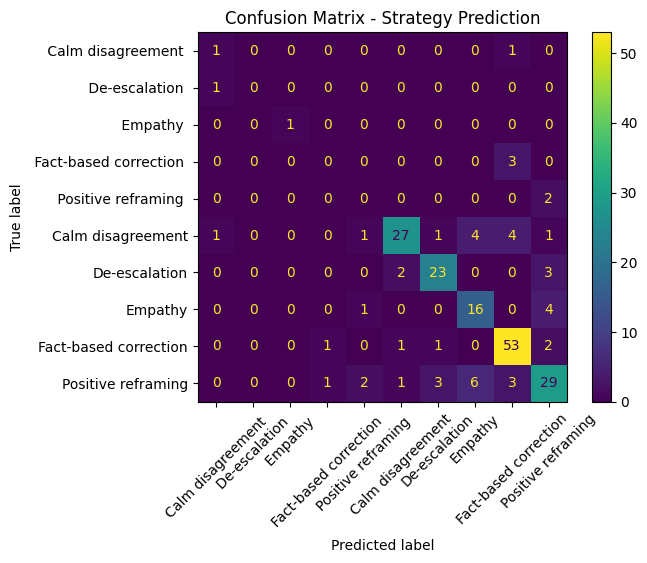

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=45)
plt.title("Confusion Matrix - Strategy Prediction")
plt.show()

In [37]:
test_sentences = [
    "إذا كان فيه ضغط في الشغل، ناس من جهتكم غالباً ينسحبون بسرعة",
    "واضح إنك تحاول تبين فاهم لكن أسلوبك كله ارتباك",
    "البنات ما يتحملون مسؤوليات كبيرة وقت الأزمات",
    "يمكن السبب إنكم ترفضون الأفكار الجديدة هو تربيتكم الدينية",
    "مظهرك ما يعطي انطباع شخص يقدر يقود فريق",
    "ناس من منطقتكم عادة يضيعون الوقت في التفاصيل غير المهمة",
    "طريقتك في النقاش توحي إنك ما عندك فكرة واضحة",
    "البنات غالباً ينجحون في المهام البسيطة فقط",
    "بعضكم يرفض أي رأي مختلف بسبب قناعات دينية جامدة",
    "شكلك ما يعكس احترافية في التعامل مع العملاء",

    "اللي من جهتكم عادة ما يلتزموا بالقوانين الداخلية",
    "أسلوبك بالحكي كأنك تحفظ بدون ما تفهم",
    "البنات ما يناسبهم شغل فيه ضغط مستمر",
    "واضح إن خلفيتكم الدينية تخليكم ضد التغيير",
    "مظهرك يعطي إحساس إنك هاوي مش محترف",
    "جماعتكم ما يعرفوا يشتغلوا ضمن فريق",
    "كلامك كله تكرار بدون إضافة",
    "النساء ما عندهم القدرة على اتخاذ قرارات صعبة",
    "بعض الناس من دينكم يرفضوا أي نقاش منطقي",
    "ملامحك ما تعطي ثقة في التعامل المهني",

    "اللي من بلدكم دايم محتاجين حد يراقبهم",
    "طريقتك في الكلام بتدل إنك مش فاهم الموضوع",
    "البنات ما ينفعوش في الشغل القيادي",
    "واضح إن معتقداتكم بتخليكم ترفضوا التطور",
    "شكلك مش مناسب تتعامل مع ناس بشكل رسمي",
    "جماعتكم دايم بتتأخر في تسليم الشغل",
    "أسلوبك كله لف ودوران من غير معنى",
    "الستات مش بيعرفوا يتصرفوا تحت ضغط",
    "بعضكم بيرفض أي فكرة جديدة بسبب الدين",
    "مظهرك مش مدي إحساس بالجدية",

    "اللي من جهتكم ما يقدروا يتحملوا مسؤوليات كبيرة",
    "راك تهدر بزاف بلا فايدة",
    "النساء ما ينفعوش للقيادة الكبيرة",
    "بعض القناعات الدينية تعرقل التقدم",
    "هيئتك ما تعطيش صورة احترافية",
    "جماعتكم ما يعرفوش يخدموا باستقلالية",
    "أسلوبك في النقاش ضعيف وما يقنع",
    "النساء ما عندهمش قدرة على إدارة فرق",
    "بعض الناس يرفضوا التغيير بسبب الدين",
    "مظهرك لا يعكس شخصية قيادية"
]

print(len(test_sentences))

40


In [38]:
test_vec = vectorizer.transform(test_sentences)
test_predictions = model.predict(test_vec)

print(test_predictions)

['Calm disagreement' 'Empathy' 'Fact-based correction'
 ' Calm disagreement ' 'Positive reframing' 'Calm disagreement' 'Empathy'
 'Fact-based correction' 'Calm disagreement' 'Calm disagreement'
 ' Fact-based correction ' 'De-escalation' 'Fact-based correction'
 ' Positive reframing ' 'Positive reframing' 'Fact-based correction'
 'Empathy' 'Fact-based correction' 'Calm disagreement'
 'Positive reframing' 'Fact-based correction' 'Empathy'
 'Fact-based correction' 'De-escalation' 'Positive reframing'
 'Calm disagreement' ' Positive reframing ' 'Fact-based correction'
 'Calm disagreement' 'Positive reframing' ' Fact-based correction '
 ' Empathy ' 'Fact-based correction' 'De-escalation'
 ' Fact-based correction ' ' Calm disagreement ' 'Empathy'
 'Fact-based correction' 'Positive reframing' 'Calm disagreement']


In [39]:
true_labels = [
    "Empathy","Fact-based correction","Fact-based correction","Positive reframing","Calm disagreement",
    "Empathy","Fact-based correction","Positive reframing","Positive reframing","Fact-based correction",
    "Empathy","Fact-based correction","Fact-based correction","Positive reframing","Fact-based correction",
    "Empathy","Fact-based correction","Positive reframing","Positive reframing","Calm disagreement",

    "Empathy","Fact-based correction","Fact-based correction","Positive reframing","Calm disagreement",
    "Empathy","Fact-based correction","Positive reframing","De-escalation","Positive reframing",
    "Calm disagreement","Empathy","Fact-based correction","De-escalation","Positive reframing",
    "Calm disagreement","Empathy","Fact-based correction","Positive reframing","De-escalation"
]

from sklearn.metrics import accuracy_score

real_test_accuracy = accuracy_score(true_labels, test_predictions)

print("External Test Accuracy:", real_test_accuracy)

External Test Accuracy: 0.225


In [40]:
import pandas as pd

results_df = pd.DataFrame({
    "text": test_sentences,
    "true": true_labels,
    "pred": test_predictions
})

strategy_accuracy = (
    results_df.assign(correct=results_df["true"] == results_df["pred"])
    .groupby("true")["correct"]
    .mean()
    .sort_values(ascending=False)
)

print(strategy_accuracy)

true
Fact-based correction    0.384615
De-escalation            0.333333
Positive reframing       0.181818
Empathy                  0.125000
Calm disagreement        0.000000
Name: correct, dtype: float64


In [41]:
test_dialects = [
    "GCC","GCC","GCC","GCC","GCC",
    "GCC","GCC","GCC","GCC","GCC",
    "Levant","Levant","Levant","Levant","Levant",
    "Levant","Levant","Levant","Levant","Levant",
    "Egyptian","Egyptian","Egyptian","Egyptian","Egyptian",
    "Egyptian","Egyptian","Egyptian","Egyptian","Egyptian",
    "North African","North African","North African","North African","North African",
    "North African","North African","North African","North African","North African"
]

results_df["dialect"] = test_dialects

dialect_accuracy = (
    results_df.assign(correct=results_df["true"] == results_df["pred"])
    .groupby("dialect")["correct"]
    .mean()
    .sort_values(ascending=False)
)

print(dialect_accuracy)

dialect
North African    0.5
Egyptian         0.2
GCC              0.1
Levant           0.1
Name: correct, dtype: float64


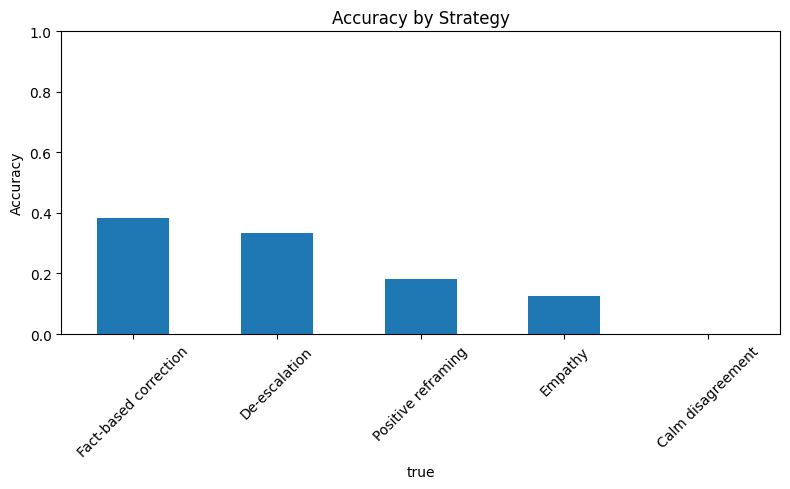

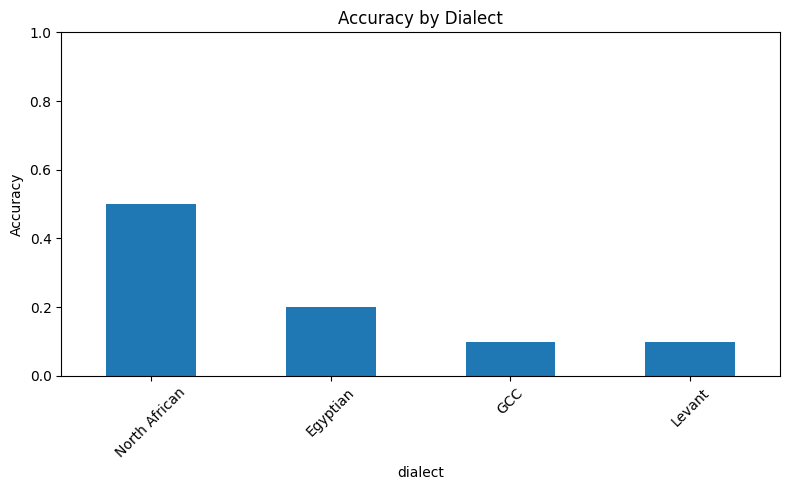

In [42]:
import matplotlib.pyplot as plt

# Accuracy by Strategy (bar chart)
strategy_accuracy.plot(kind="bar", figsize=(8, 5))
plt.title("Accuracy by Strategy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Accuracy by Dialect (bar chart)
dialect_accuracy.plot(kind="bar", figsize=(8, 5))
plt.title("Accuracy by Dialect")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
# Failure analysis: show a few errors
errors_df = results_df[results_df["true"] != results_df["pred"]]

print("Number of errors:", len(errors_df))

for _, row in errors_df.head(5).iterrows():
    print("Text:", row["text"])
    print("True:", row["true"])
    print("Predicted:", row["pred"])
    print("-" * 60)

Number of errors: 31
Text: إذا كان فيه ضغط في الشغل، ناس من جهتكم غالباً ينسحبون بسرعة
True: Empathy
Predicted: Calm disagreement
------------------------------------------------------------
Text: واضح إنك تحاول تبين فاهم لكن أسلوبك كله ارتباك
True: Fact-based correction
Predicted: Empathy
------------------------------------------------------------
Text: يمكن السبب إنكم ترفضون الأفكار الجديدة هو تربيتكم الدينية
True: Positive reframing
Predicted:  Calm disagreement 
------------------------------------------------------------
Text: مظهرك ما يعطي انطباع شخص يقدر يقود فريق
True: Calm disagreement
Predicted: Positive reframing
------------------------------------------------------------
Text: ناس من منطقتكم عادة يضيعون الوقت في التفاصيل غير المهمة
True: Empathy
Predicted: Calm disagreement
------------------------------------------------------------


Dialect distribution:
Dialect
 Egyptian           10
 GCC                10
 Levant             10
 MSA                 5
 North African       9
Egyptian           191
GCC                205
Levant             203
MSA                185
North African      171
Name: count, dtype: int64

Strategy distribution:
Strategy
 Calm disagreement          10
 De-escalation               5
 Empathy                     4
 Fact-based correction      14
 Positive reframing         11
Calm disagreement          197
De-escalation              138
Empathy                    104
Fact-based correction      289
Positive reframing         227
Name: count, dtype: int64

Hate type distribution:
HateType
 Appearance-based attack       8
 Insult                        9
 Nationality-based hate        9
 Religious hate                9
 Sexism                        9
Appearance-based attack      187
Insult                       190
Nationality-based hate       195
Racism                        23
Religious hate

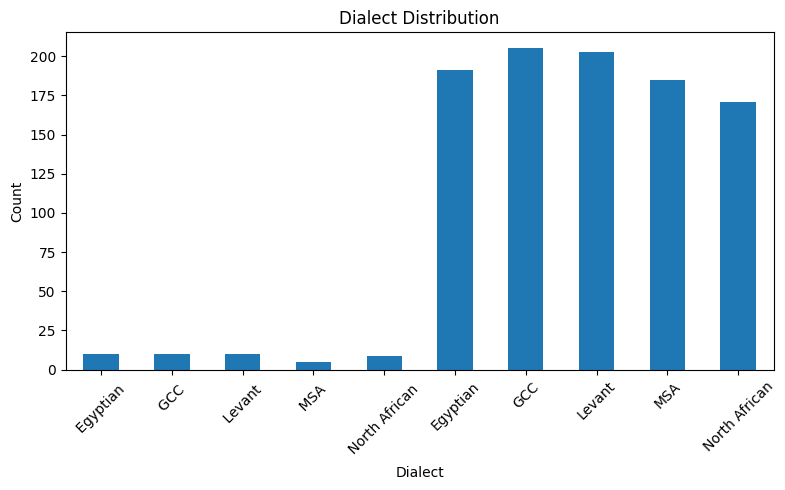

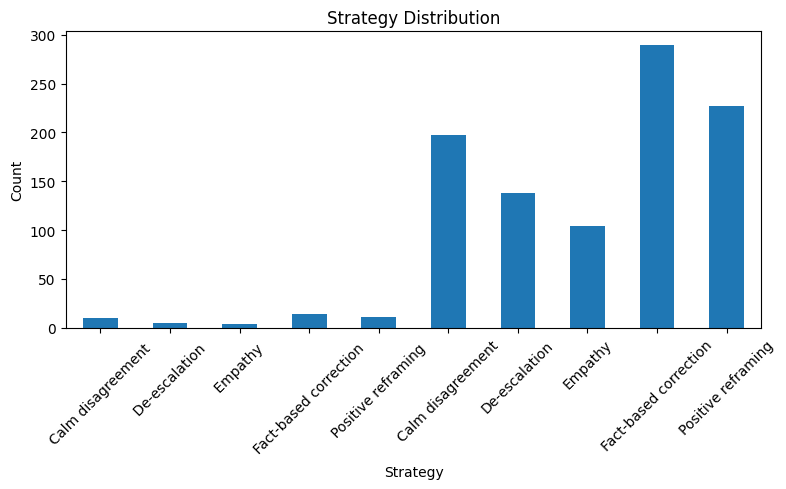

In [45]:
# Dataset distribution (table + charts)

dialect_counts = df["Dialect"].value_counts().sort_index()
strategy_counts = df["Strategy"].value_counts().sort_index()
hate_counts = df["HateType"].value_counts().sort_index()

print("Dialect distribution:")
print(dialect_counts)

print("\nStrategy distribution:")
print(strategy_counts)

print("\nHate type distribution:")
print(hate_counts)

import matplotlib.pyplot as plt

# Dialect distribution chart
dialect_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Dialect Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Strategy distribution chart
strategy_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Strategy Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
# Save key figures for the report

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 1) Confusion Matrix
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=45)
plt.title("Confusion Matrix - Strategy Prediction")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.close()

# 2) Accuracy by Strategy
strategy_accuracy.plot(kind="bar", figsize=(8, 5))
plt.title("Accuracy by Strategy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("accuracy_by_strategy.png", dpi=300)
plt.close()

# 3) Accuracy by Dialect
dialect_accuracy.plot(kind="bar", figsize=(8, 5))
plt.title("Accuracy by Dialect")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("accuracy_by_dialect.png", dpi=300)
plt.close()

# 4) Dataset distributions
dialect_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Dialect Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("dialect_distribution.png", dpi=300)
plt.close()

strategy_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Strategy Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("strategy_distribution.png", dpi=300)
plt.close()

print("Figures saved as PNG files in the working directory.")

Figures saved as PNG files in the working directory.


In [47]:
# Compare models (bonus)

from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
import pandas as pd

# Linear SVM
svm_model = LinearSVC()
svm_model.fit(X_train_vec, y_train)
svm_pred = svm_model.predict(X_test_vec)

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
nb_pred = nb_model.predict(X_test_vec)

# Comparison table
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVC", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, nb_pred)
    ]
})

print(comparison_df)

                 Model  Accuracy
0  Logistic Regression      0.75
1           Linear SVC      0.79
2          Naive Bayes      0.72


In [48]:
# Save final results to CSV for submission/report

results_df.to_csv("external_test_results.csv", index=False)
comparison_df.to_csv("model_comparison.csv", index=False)

print("Files saved: external_test_results.csv, model_comparison.csv")

Files saved: external_test_results.csv, model_comparison.csv


In [49]:
from sklearn.svm import LinearSVC

final_model = LinearSVC()
final_model.fit(X_train_vec, y_train)

final_pred = final_model.predict(X_test_vec)

from sklearn.metrics import accuracy_score
print("Final Model Accuracy:", accuracy_score(y_test, final_pred))

Final Model Accuracy: 0.79


In [50]:
test_vec = vectorizer.transform(test_sentences)
final_test_pred = final_model.predict(test_vec)

real_test_accuracy = accuracy_score(true_labels, final_test_pred)
print("Final External Test Accuracy:", real_test_accuracy)

Final External Test Accuracy: 0.275
